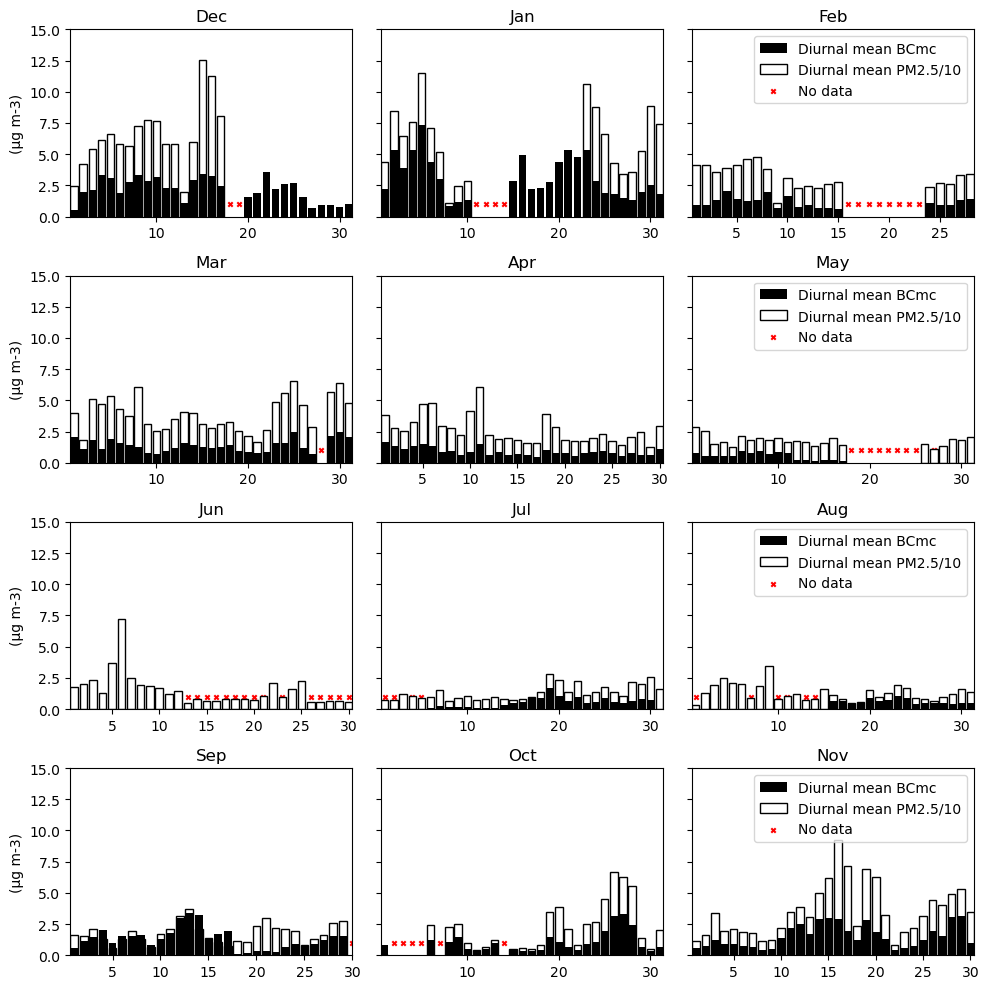

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1.Load dataframe
df = pd.read_csv('data/slcp_metdata_aio_2019-2021.csv', index_col=0, parse_dates=True)

# Select 2019-2021 data
# years = [2019, 2020, 2021]
year = 2021
df = df.loc[df.index.year == year]
species = "BC"

# 2.Vectorized calculation
# Convert direction to radians inside the formula
df['u'] = -df['wspd'] * np.sin(np.deg2rad(df['wdir']))
df['v'] = -df['wspd'] * np.cos(np.deg2rad(df['wdir']))
df['lon'] = 105.8
df['lat'] = 21.6

# 3.Plot
# fig, ax = plt.subplots()
# ax.barbs(df['lon'],df['lat'], df['u'], df['v'])

# Create a dictionary of seasons and months
seasons = {'Winter': ['Dec', 'Jan', 'Feb'],
           'Spring': ['Mar', 'Apr', 'May'],
           'Summer': ['Jun', 'Jul', 'Aug'],
           'Fall': ['Sep', 'Oct', 'Nov']}

# Create subplots for each season
fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(10, 10))
# Loop through each season and month
for i, (season, months) in enumerate(seasons.items()):
    for j, month in enumerate(months):
        # Get the data for the month
        data = df.loc[df.index.month == pd.to_datetime(month, format='%b').month]

        # Resample diurnal mean for each day in the month
        bc1d = data['BC'].resample('D').mean()
        pm1dtenth = data['PM2.5'].resample('D').mean() / 10
        # wind = data[species].resample('D').mean()

        # Mark the nan values
        mask = bc1d.isna()
        mask = mask[mask == True]  

        # Plot the data
        axs[i][j].scatter(mask.index.day, mask, color='red', label='No BC data', marker='x', s=10) # Plot the nan values
        p2 = axs[i][j].bar(pm1dtenth.index.day, pm1dtenth.values, label='Diurnal mean PM2.5/10', color='white', edgecolor='black')
        p1 = axs[i][j].bar(bc1d.index.day, bc1d.values, label='Diurnal mean BCmc', color='black')
        # p3 = axs[i][j].scatter(wind.index.day, rushhours.values, label='Rush hours', color='green', marker='^')
        


        axs[i][j].set_title(month)
        axs[i][j].set_ylim(0, 15)
        axs[i][0].set_ylabel('(μg m-3)')
        

        # Clear margins
        axs[i][j].margins(x=0)
        # axs[i][j].set_xlabel('Day')
        axs[i][1].set_yticklabels([])
        axs[i][2].set_yticklabels([])
        # Set legend
        # axs[i][2].legend(['No data', 'Daytime', 'Nighttime'], loc='upper right')
        handles, labels = axs[i][2].get_legend_handles_labels()
        axs[i][2].legend(handles[::-1], labels[::-1], loc='upper right')

    # Set the title for each row
    # axs[i][0].set_title(season)
    
# Set title for figure
# fig.suptitle(f'Diurnal average of {species} Mass Concentration in {year}', fontsize=12)
plt.tight_layout()
plt.show()